In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
from main_accuracy import main

In [4]:
from pathlib import Path

ROOT_DATA_DIR = Path("../data/")
plots_root_dir = Path('../tex/Figures/plots')

In [5]:
from contextlib import contextmanager
import logging

@contextmanager
def all_logging_disabled(highest_level=logging.CRITICAL):
    """
    A context manager that will prevent any logging messages
    triggered during the body from being processed.
    :param highest_level: the maximum logging level in use.
      This would only need to be changed if a custom level greater than CRITICAL
      is defined.
    """
    # two kind-of hacks here:
    #    * can't get the highest logging level in effect => delegate to the user
    #    * can't get the current module-level override => use an undocumented
    #       (but non-private!) interface

    previous_level = logging.root.manager.disable

    logging.disable(highest_level)

    try:
        yield
    finally:
        logging.disable(previous_level)

In [6]:
model_name = 'Transformer'
dataset_name = 'KPI'

/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

Sanity Checking: 0it [00:00, ?it/s]

/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

LinearTransformer
NAB & 0.49/0.55 & 0.12/0.27 & 0.75/0.73 & 0.21/0.40



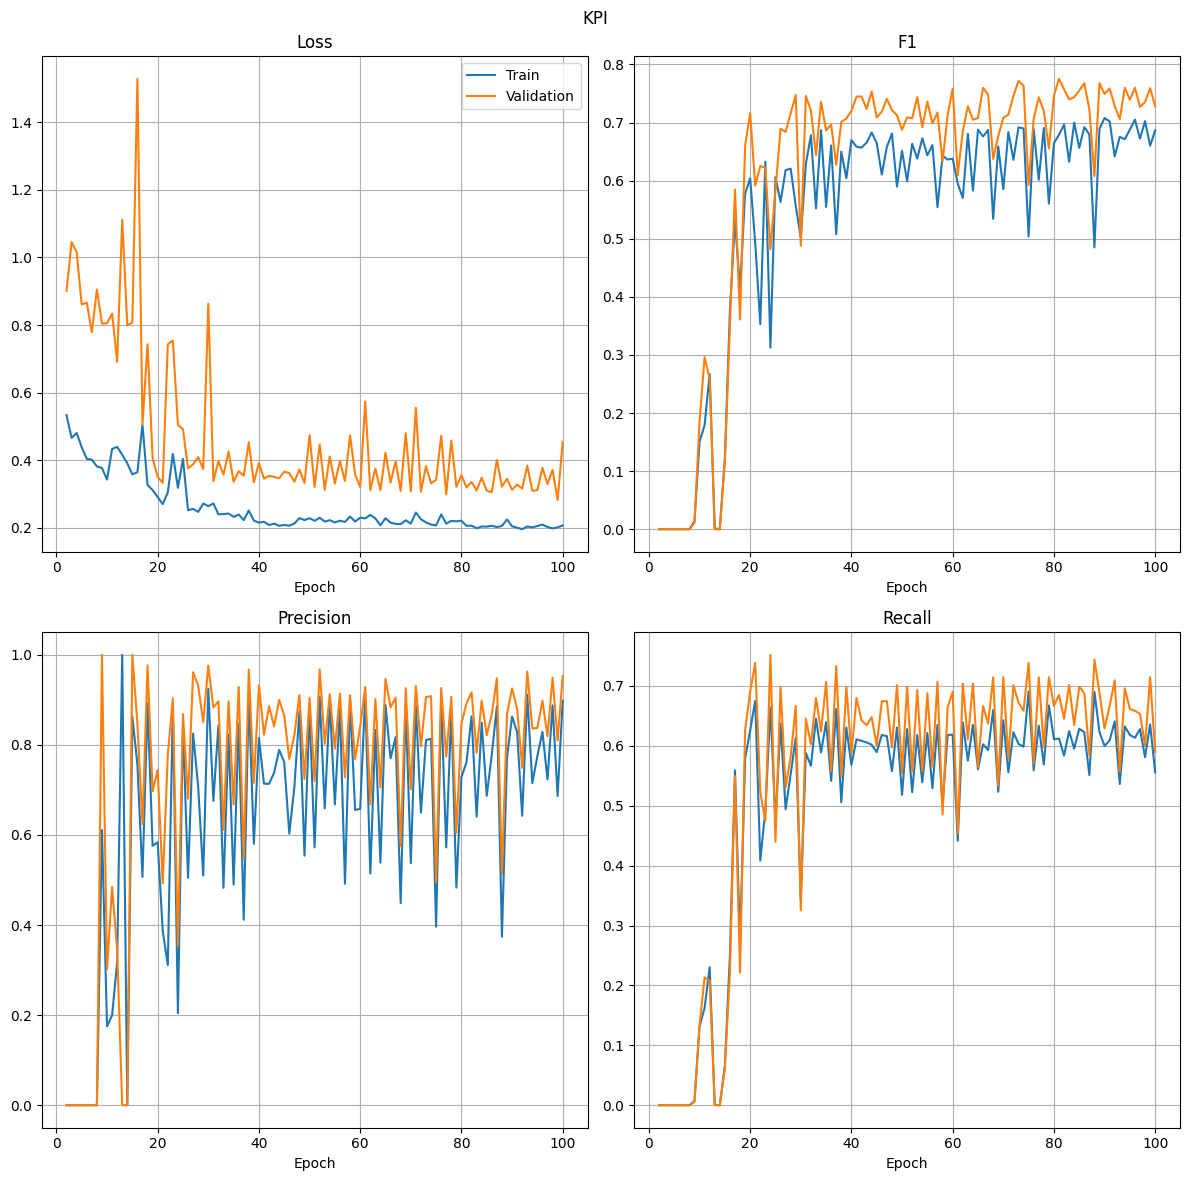

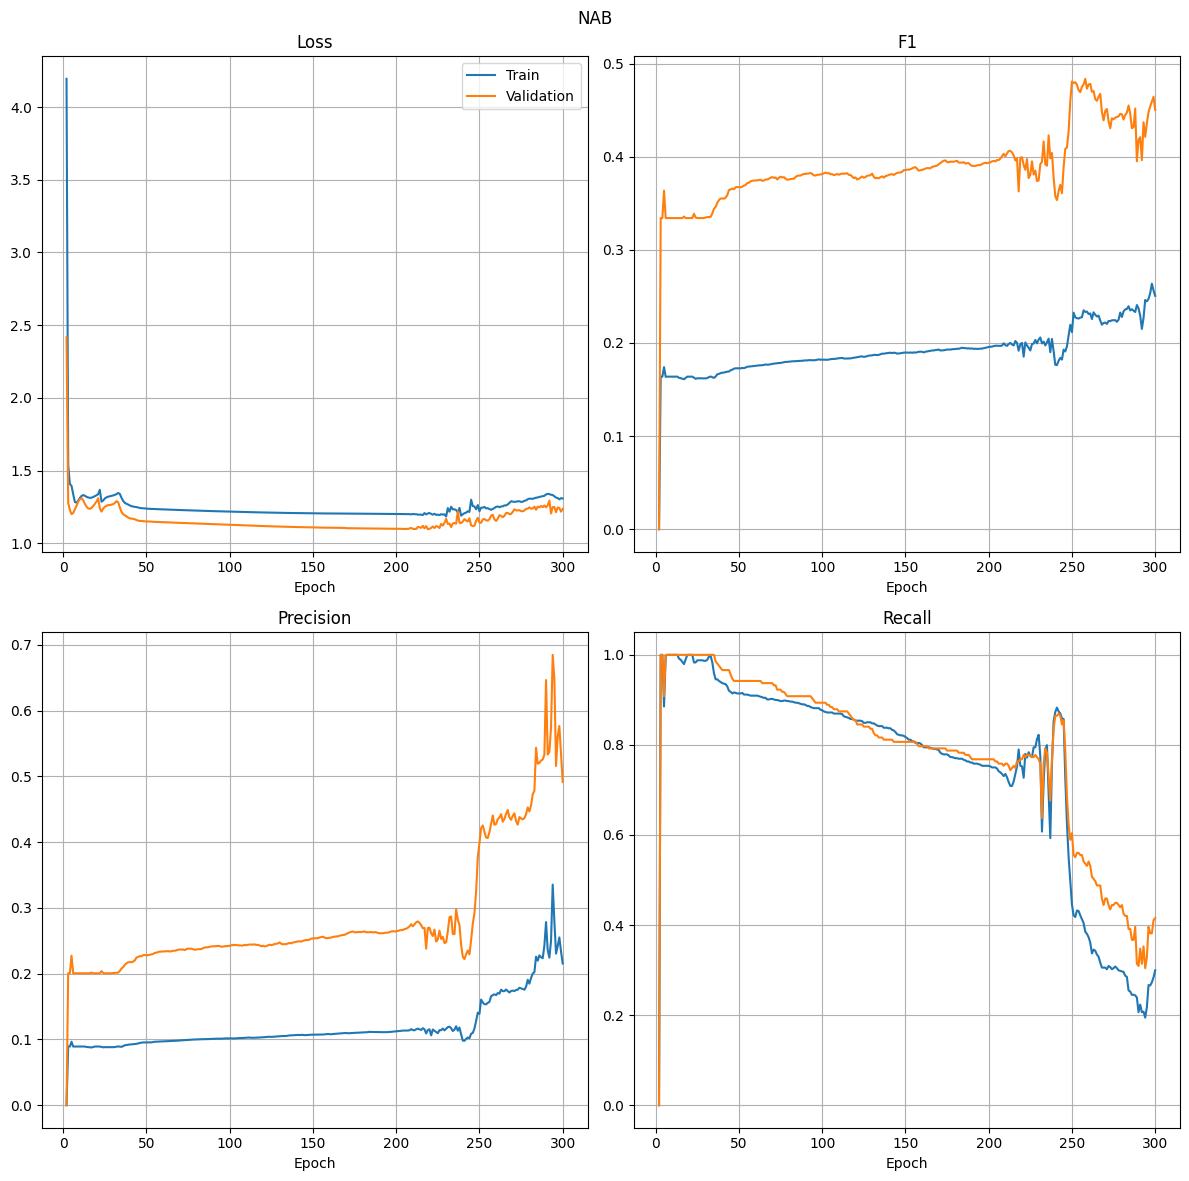

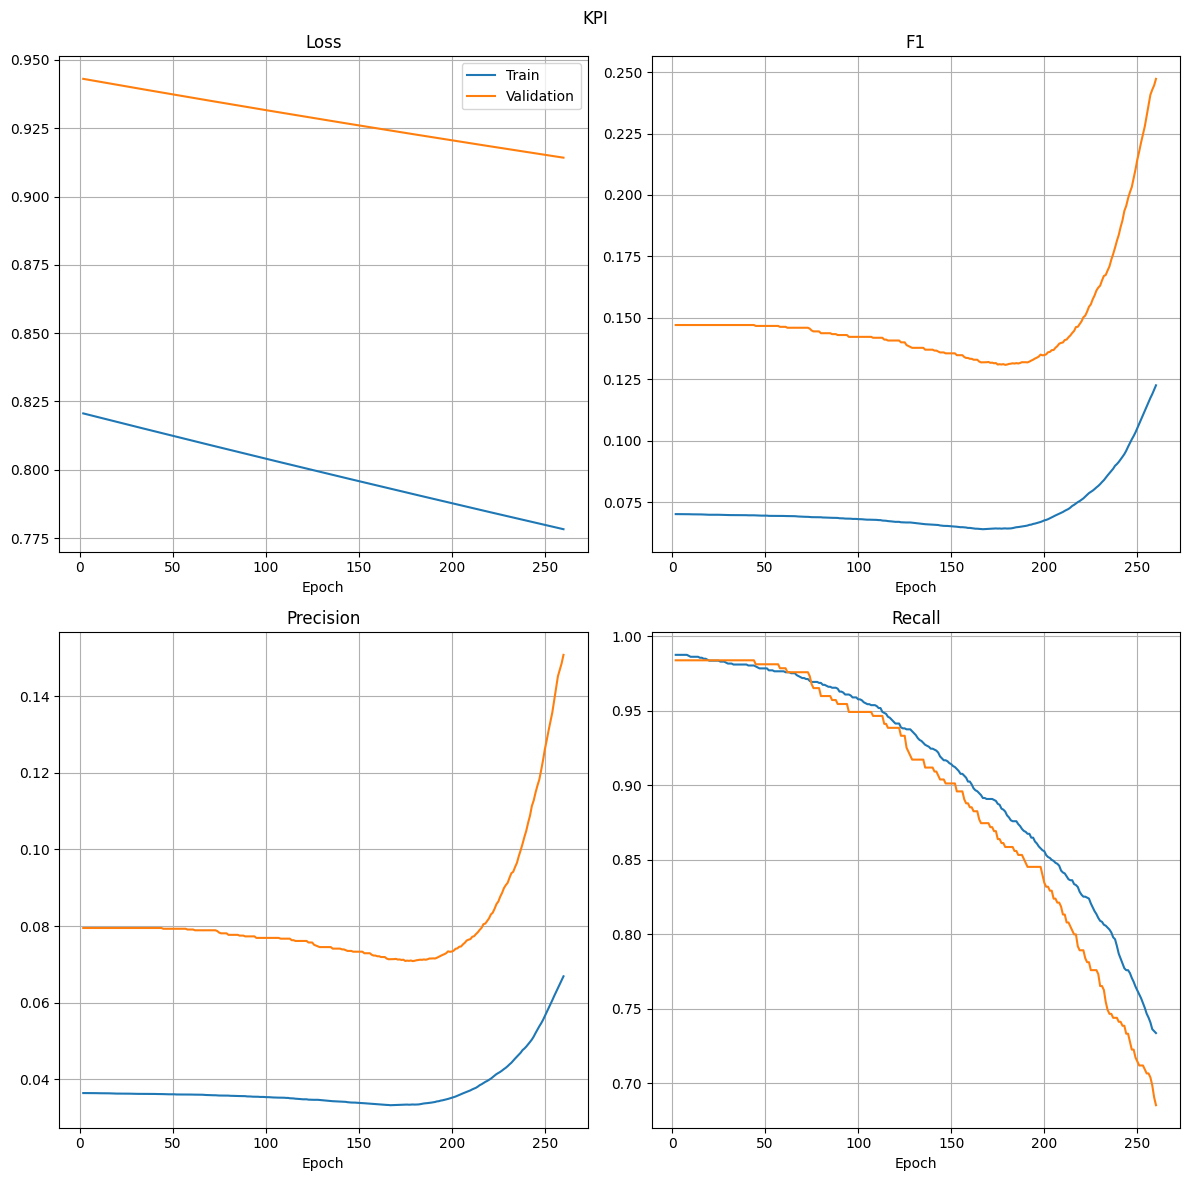

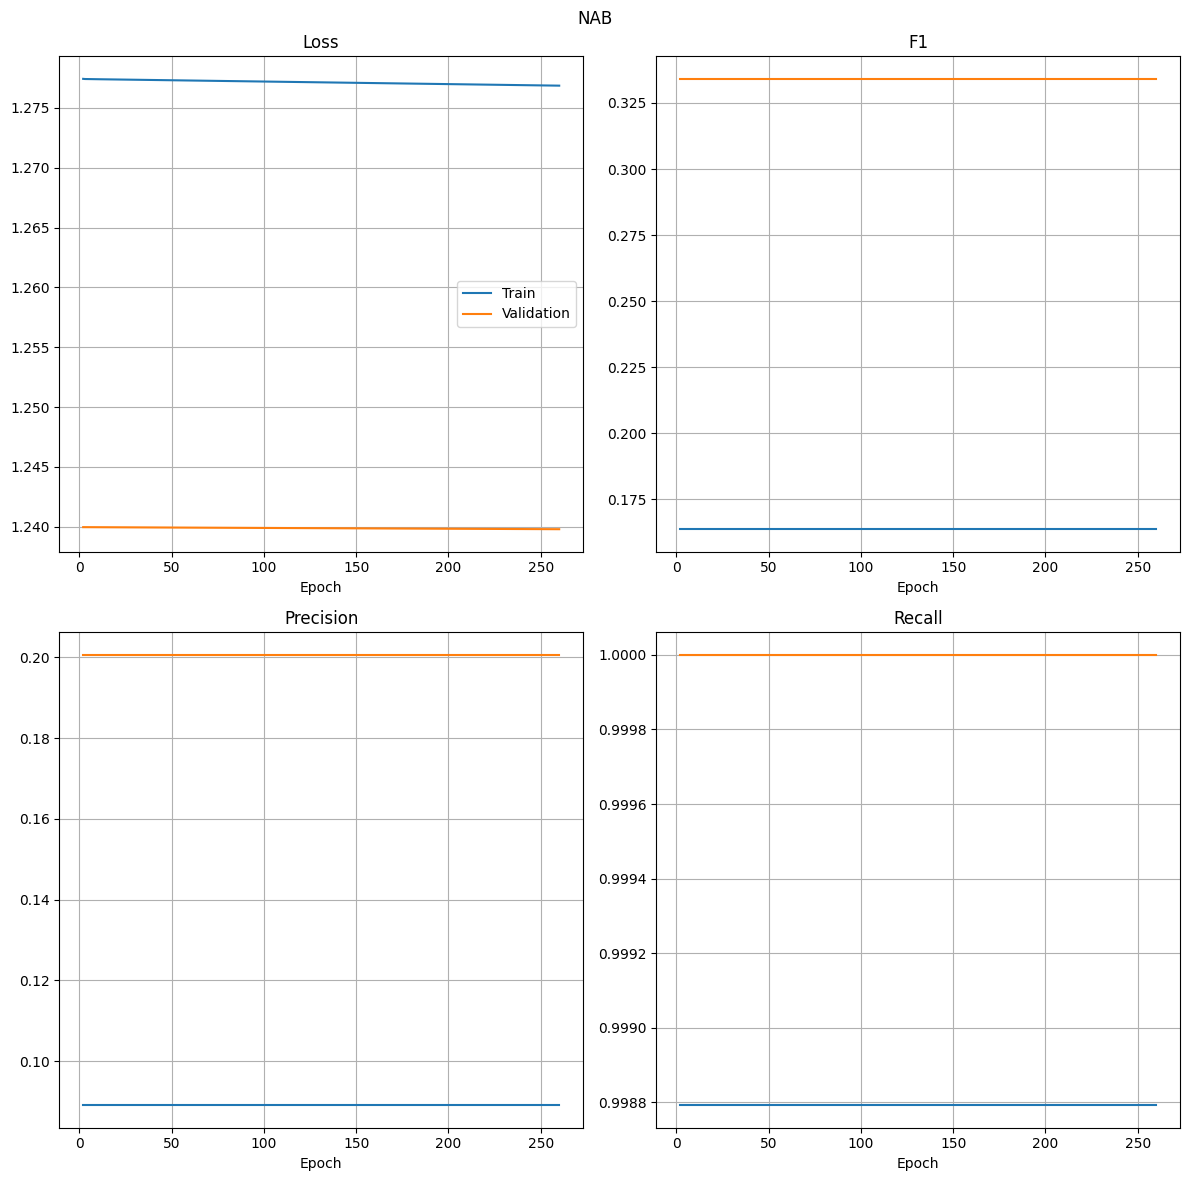

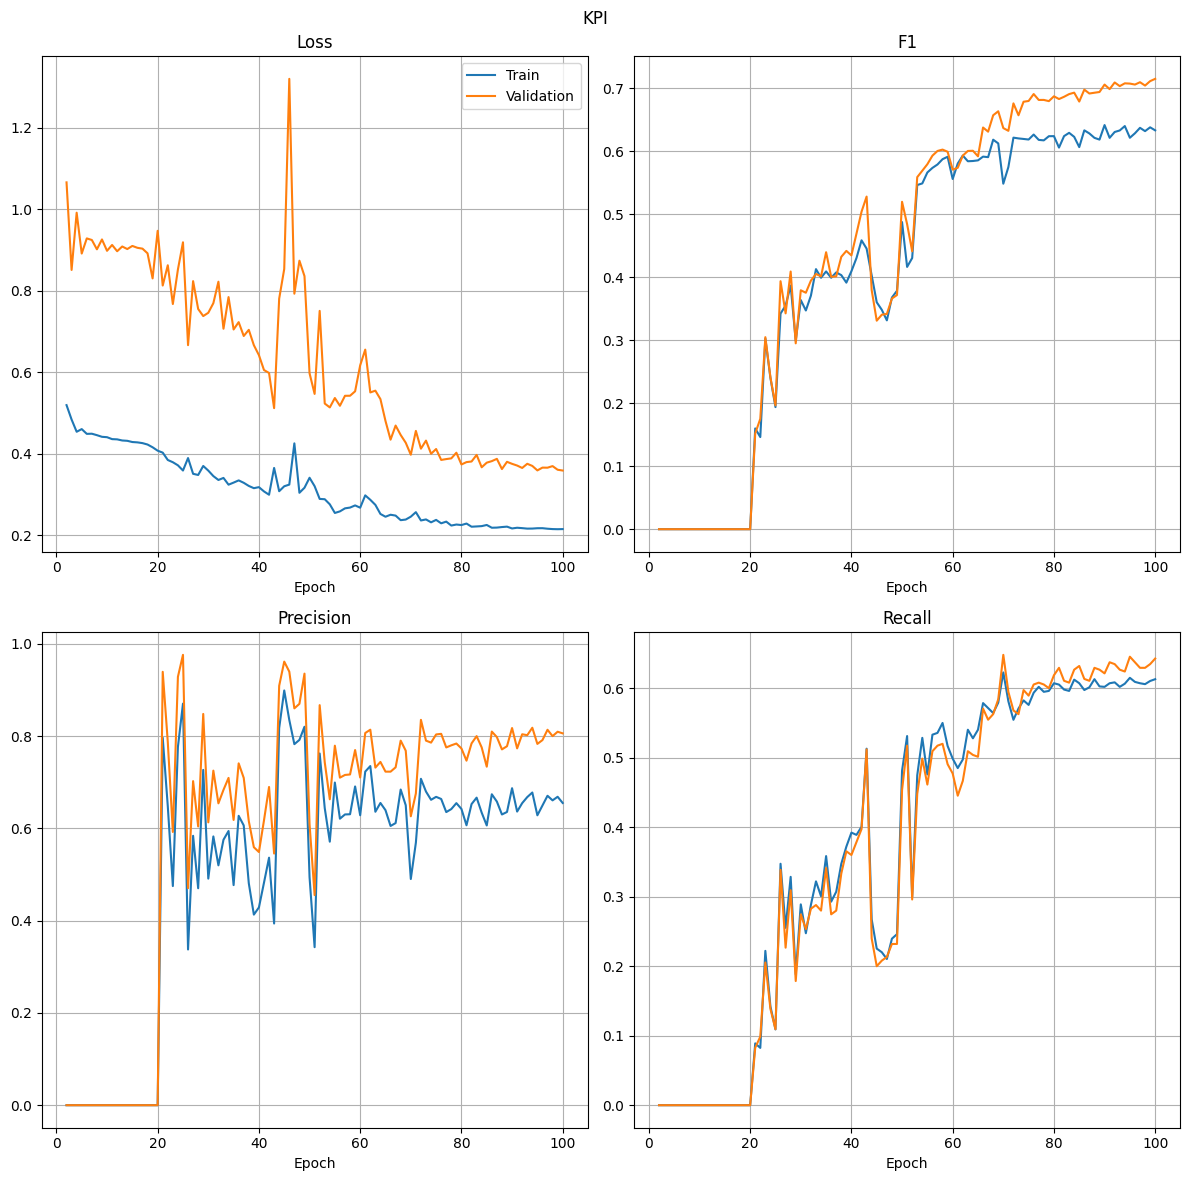

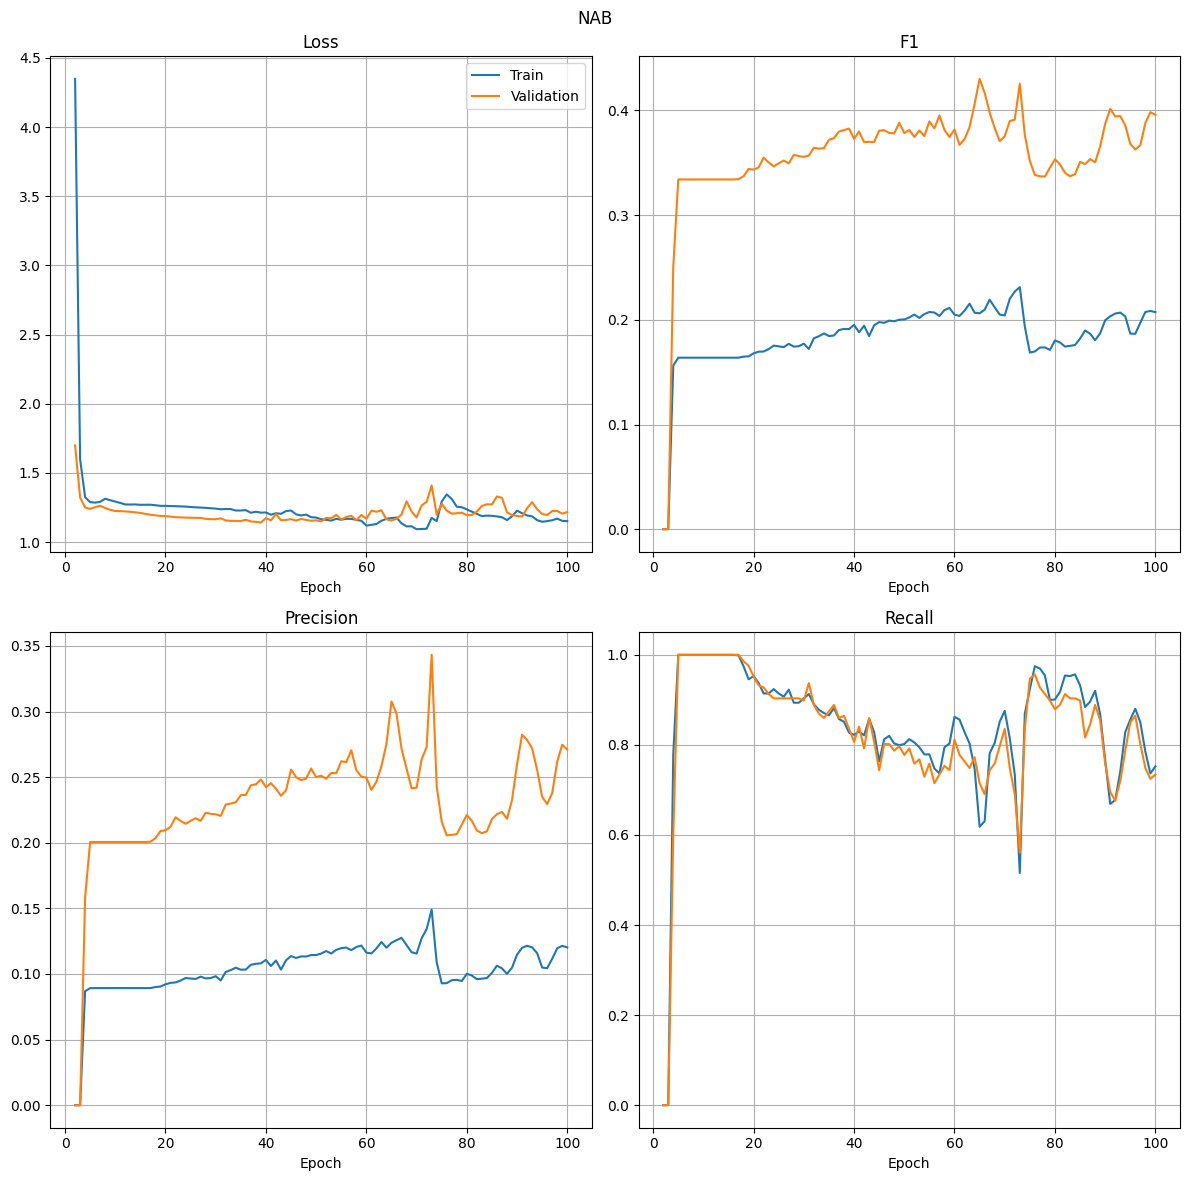

In [7]:
for model_name in ['Transformer', 'LinearRegression', 'LinearTransformer']:
    for dataset_name in ['KPI', 'NAB']:
        with all_logging_disabled():
            return_dict = main(model_name=model_name, dataset_name=dataset_name, plots_root_dir=plots_root_dir, root_data_dir=ROOT_DATA_DIR)
            metrics_res = return_dict['metrics']
            
            res_str = f'{dataset_name} & '
            res_list = []
            
            for metric_name in ['accuracy', 'precision', 'recall', 'f1']:
                res_small = []
                for train_or_val in ['train', 'val']:
                    v = metrics_res.iloc[-1][f'{train_or_val}_{metric_name}']
                    v = f'{v:.2f}'
                    res_small.append(v)
                res_small = '/'.join(res_small)
                res_list.append(res_small)
            print(model_name)
            print(res_str + (' & '.join(res_list)))
            print()

## export models parameters (linear transformer)

In [8]:
import gc
gc.collect()

87545

In [9]:
import torch

In [10]:
model_name = 'LinearTransformer'
dataset_name = 'NAB'

In [11]:
torch.set_grad_enabled(True)
return_dict = main(model_name=model_name, dataset_name=dataset_name, plots_root_dir=plots_root_dir, root_data_dir=ROOT_DATA_DIR)

Global seed set to 1
Global seed set to 1
src.utils    2026-05-17 02:37:29,599: INFO     Dataset shape: (10319, 4)
src.utils    2026-05-17 02:37:29,639: INFO     x.shape: torch.Size([10311, 8, 2]), y.shape: torch.Size([10311])
src.utils    2026-05-17 02:37:29,645: INFO     train_idx: 9279
src.utils    2026-05-17 02:37:29,651: WARNING  y_tr mean 0.08923375606536865, y_va mean 0.2005814015865326
src.utils    2026-05-17 02:37:29,654: INFO     tr_dataset: 9279, va_dataset: 1032
Global seed set to 1
src.transformer 2026-05-17 02:37:29,669: INFO     layer norm enabled: False
src.transformer 2026-05-17 02:37:29,673: WARNING  layer norm disabled
src.transformer 2026-05-17 02:37:29,675: INFO     positional encoding enabled: False
src.transformer 2026-05-17 02:37:29,676: WARNING  positional encoding disabled
main_accuracy 2026-05-17 02:37:29,677: INFO     Training model: LinearTransformer on dataset: NAB for 100 epochs. Input dim: 2
GPU available: False, used: False
TPU available: False, using: 

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.08511380382023763
Restoring states from the checkpoint path at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_36160943-0a33-4585-97d7-e46a459727a5.ckpt
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_36160943-0a33-4585-97d7-e46a459727a5.ckpt

  | Name                | Type                     | Params
-----------------------------------------------------------------
0 | front_linear        | Linear                   | 24    
1 | transformer_encoder | LinearTransformerEncoder | 544   
2 | positional_encoder  | Identity                 | 0     
3 | final_linear        | Linear                   | 9     
4 | loss_fn             | BCEWithLogitsLoss        | 0     
-----------------------------------------------------------------
577       Trainable params
0         Non-trainable params
577       Total params
0.002     Total estimated model

Sanity Checking: 0it [00:00, ?it/s]

/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.
main_accuracy 2026-05-17 02:37:57,815: INFO     Plotting metrics to ../tex/Figures/plots


In [12]:
torch.set_grad_enabled(False)

In [13]:
model = return_dict['model']

In [14]:
model

LinearTransformerAnomalyDetector(
  (front_linear): Linear(in_features=2, out_features=8, bias=True)
  (transformer_encoder): LinearTransformerEncoder(
    (layers): ModuleList(
      (0): LinearEncoderBlock(
        (self_attn): LinearAttention(
          (query_mat): Linear(in_features=8, out_features=8, bias=False)
          (key_mat): Linear(in_features=8, out_features=8, bias=False)
          (value_mat): Linear(in_features=8, out_features=8, bias=False)
          (o_proj): Linear(in_features=8, out_features=8, bias=True)
          (feature_map): FeatureMap()
        )
        (linear_net): Sequential(
          (0): Linear(in_features=8, out_features=16, bias=True)
          (1): Dropout(p=0.0, inplace=False)
          (2): ReLU(inplace=True)
          (3): Linear(in_features=16, out_features=8, bias=True)
        )
        (norm1): Identity()
        (norm2): Identity()
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (positional_encoder): Identity()
  (final

In [15]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model's state_dict:
front_linear.weight 	 torch.Size([8, 2])
front_linear.bias 	 torch.Size([8])
transformer_encoder.layers.0.self_attn.query_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.key_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.value_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.o_proj.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.o_proj.bias 	 torch.Size([8])
transformer_encoder.layers.0.linear_net.0.weight 	 torch.Size([16, 8])
transformer_encoder.layers.0.linear_net.0.bias 	 torch.Size([16])
transformer_encoder.layers.0.linear_net.3.weight 	 torch.Size([8, 16])
transformer_encoder.layers.0.linear_net.3.bias 	 torch.Size([8])
final_linear.weight 	 torch.Size([1, 8])
final_linear.bias 	 torch.Size([1])
loss_fn.pos_weight 	 torch.Size([])


In [16]:
template_params = 'inline constexpr static float %s%s = %s;'
with open('../vitis_hls/linear_transformer/scaled_dp_params.h', 'w') as f:
    for name, param in model.named_parameters():
        n = name.upper()
        # s = param.size()
        n = n.replace('.', '_')
        WT = param.T
        shape_str = ''.join([f'[{x}]' for x in WT.shape])
        if len(WT.shape) == 2:
            weights_arr = []
            for row in WT:
                row_str = '{' + ', '.join([f'{x:.6f}' for x in row]) + '}'
                weights_arr.append(row_str)
            weights_str = '{' + ',\n'.join(weights_arr) + '}'
        elif len(WT.shape) == 1:
            row = WT
            row_str = '{' + ', '.join([f'{x:.6f}' for x in row]) + '}'
            weights_str = row_str
        else:
            raise NotImplementedError(WT.shape)
        # p = [f'{x:.6f}' for x in param.T.ravel().detach().numpy()]
        # l = len(p)
        # p = ', '.join(p)
        print(template_params % (n, shape_str, weights_str), file=f)

/tmp/ipykernel_1525925/4006788644.py:7: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3571.)
  WT = param.T


In [17]:
xx = torch.tensor([[
    [0.2, 0.2],
    [0.2, 0.2],
    [0.4, 0.4],
    [0.4, 0.4],
    [0.6, 0.6],
    [0.6, 0.6],
    [0.8, 0.8],
    [0.8, 0.8],
]]).float()
model(xx)

tensor([-2.5700])

In [18]:
prev = xx

### front linear

see https://danielcoelho.substack.com/p/pytorch-and-neural-network-conventions for description of conventions

In [19]:
layer = model.front_linear
W = layer.weight
b = layer.bias

In [20]:
W.T

tensor([[ 0.5849, -0.4985, -1.5052, -0.3525,  0.3912,  1.1737,  1.1318,  0.2905],
        [-1.0173,  0.4711,  0.3119,  0.3221,  0.4991,  0.5599, -0.4627, -0.1102]],
       requires_grad=True)

In [21]:
out = torch.matmul(prev, W.T) + b
out = out.numpy()
out_real = layer(prev).numpy()

In [22]:
np.allclose(out, out_real)

True

In [23]:
out_real.round(2)

array([[[-0.73,  0.04,  0.28,  0.08,  0.09,  0.25,  0.07, -0.11],
        [-0.73,  0.04,  0.28,  0.08,  0.09,  0.25,  0.07, -0.11],
        [-0.82,  0.04,  0.04,  0.07,  0.26,  0.6 ,  0.2 , -0.07],
        [-0.82,  0.04,  0.04,  0.07,  0.26,  0.6 ,  0.2 , -0.07],
        [-0.91,  0.03, -0.2 ,  0.07,  0.44,  0.95,  0.34, -0.03],
        [-0.91,  0.03, -0.2 ,  0.07,  0.44,  0.95,  0.34, -0.03],
        [-0.99,  0.02, -0.44,  0.06,  0.62,  1.29,  0.47,  0.  ],
        [-0.99,  0.02, -0.44,  0.06,  0.62,  1.29,  0.47,  0.  ]]],
      dtype=float32)

In [24]:
prev = torch.Tensor(out_real)

### query

In [25]:
layer = model.transformer_encoder.layers[0].self_attn.query_mat
W = layer.weight
# b = layer.bias

In [26]:
out = torch.matmul(prev, W.T) #+ b
out = out.numpy()
out_real = layer(prev).numpy()

In [27]:
np.allclose(out, out_real)

True

In [28]:
out_real.round(2)

array([[[ 1.93, -1.29,  0.47,  0.77, -0.2 ,  0.48, -1.1 , -1.67],
        [ 1.93, -1.29,  0.47,  0.77, -0.2 ,  0.48, -1.1 , -1.67],
        [ 2.49, -1.94,  0.48,  0.53, -0.6 ,  0.09, -1.89, -2.43],
        [ 2.49, -1.94,  0.48,  0.53, -0.6 ,  0.09, -1.89, -2.43],
        [ 3.06, -2.6 ,  0.5 ,  0.3 , -1.  , -0.3 , -2.68, -3.18],
        [ 3.06, -2.6 ,  0.5 ,  0.3 , -1.  , -0.3 , -2.68, -3.18],
        [ 3.63, -3.25,  0.51,  0.06, -1.4 , -0.68, -3.46, -3.94],
        [ 3.63, -3.25,  0.51,  0.06, -1.4 , -0.68, -3.46, -3.94]]],
      dtype=float32)

In [29]:
prev_query = torch.Tensor(out_real)

### key

In [30]:
layer = model.transformer_encoder.layers[0].self_attn.key_mat
W = layer.weight
# b = layer.bias

In [31]:
out = torch.matmul(prev, W.T) #+ b
out = out.numpy()
out_real = layer(prev).numpy()

In [32]:
np.allclose(out, out_real)

True

In [33]:
out_real.round(2)

array([[[-0.81,  1.82, -1.32, -0.88, -0.86,  0.5 ,  1.29,  0.68],
        [-0.81,  1.82, -1.32, -0.88, -0.86,  0.5 ,  1.29,  0.68],
        [-0.87,  0.57, -1.41, -1.48, -1.02,  1.86, -0.02,  0.64],
        [-0.87,  0.57, -1.41, -1.48, -1.02,  1.86, -0.02,  0.64],
        [-0.93, -0.68, -1.5 , -2.08, -1.19,  3.23, -1.33,  0.59],
        [-0.93, -0.68, -1.5 , -2.08, -1.19,  3.23, -1.33,  0.59],
        [-0.99, -1.92, -1.59, -2.68, -1.35,  4.59, -2.63,  0.54],
        [-0.99, -1.92, -1.59, -2.68, -1.35,  4.59, -2.63,  0.54]]],
      dtype=float32)

In [34]:
prev_key = torch.Tensor(out_real)

### value

In [35]:
layer = model.transformer_encoder.layers[0].self_attn.value_mat
W = layer.weight
# b = layer.bias

In [36]:
out = torch.matmul(prev, W.T) #+ b
out = out.numpy()
out_real = layer(prev).numpy()

In [37]:
np.allclose(out, out_real)

True

In [38]:
out_real.round(2)

array([[[ 0.66,  0.1 ,  0.36,  0.24,  0.61,  0.76, -0.07,  0.53],
        [ 0.66,  0.1 ,  0.36,  0.24,  0.61,  0.76, -0.07,  0.53],
        [ 0.54, -0.83,  0.14, -0.11,  0.41,  0.32, -1.02, -0.15],
        [ 0.54, -0.83,  0.14, -0.11,  0.41,  0.32, -1.02, -0.15],
        [ 0.42, -1.76, -0.08, -0.47,  0.22, -0.13, -1.97, -0.83],
        [ 0.42, -1.76, -0.08, -0.47,  0.22, -0.13, -1.97, -0.83],
        [ 0.31, -2.69, -0.3 , -0.82,  0.03, -0.58, -2.91, -1.52],
        [ 0.31, -2.69, -0.3 , -0.82,  0.03, -0.58, -2.91, -1.52]]],
      dtype=float32)

In [39]:
prev_value = torch.Tensor(out_real)

### feature map (ELU)

In [40]:
ins = torch.linspace(-1, 1, 100)
vals = torch.nn.functional.elu(ins)

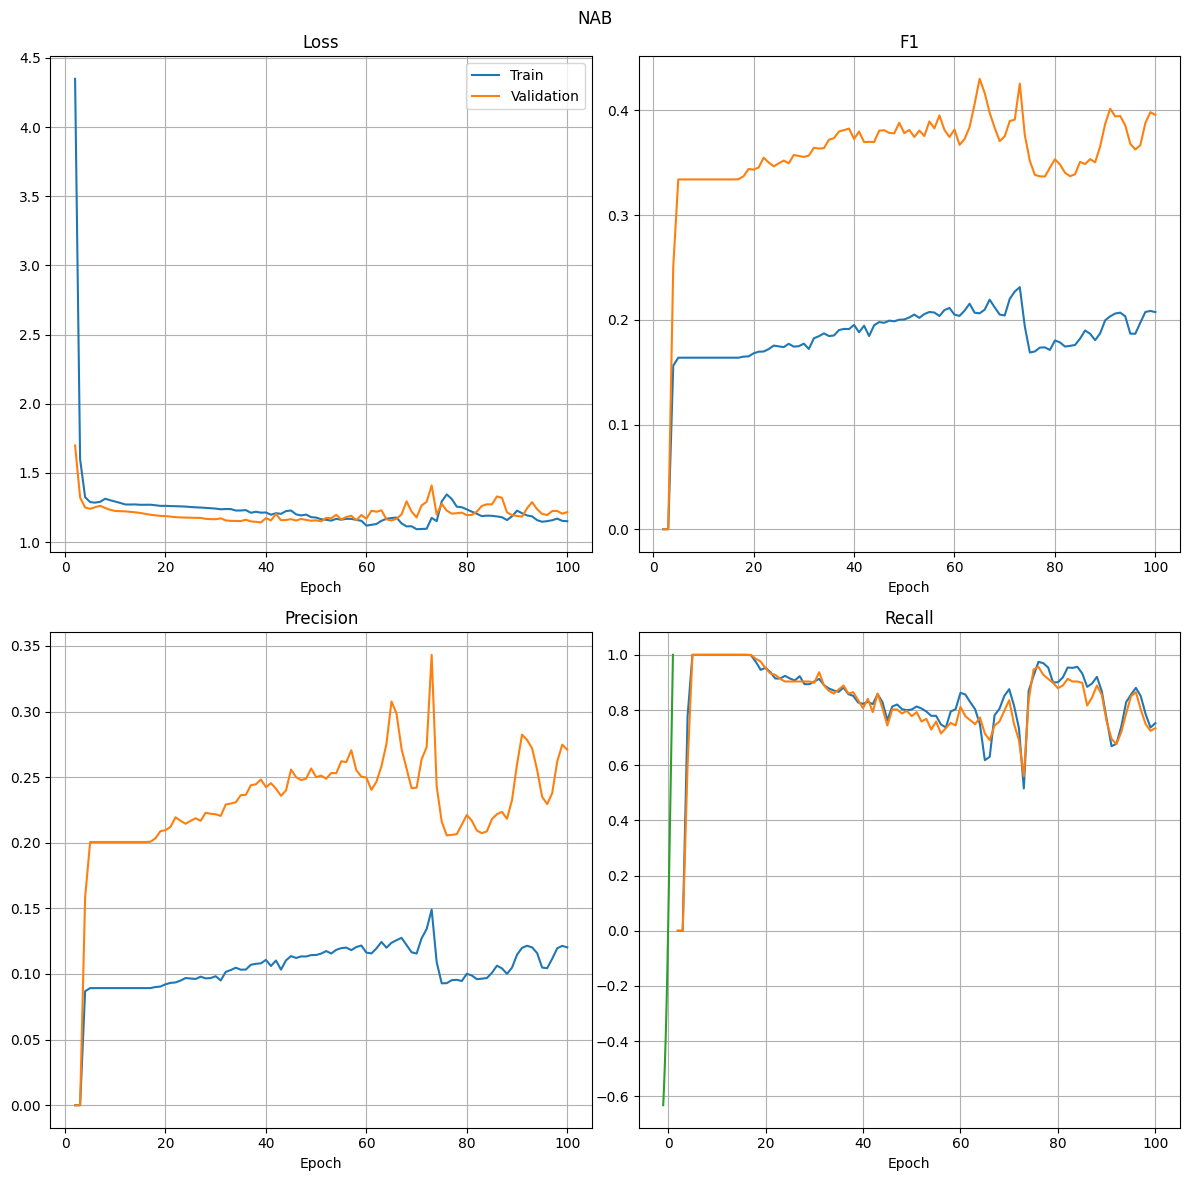

In [41]:
plt.plot(ins, vals)
plt.show()

### kv^T

In [42]:
from copy import deepcopy

In [43]:
q = torch.nn.functional.elu(prev_query)
k = torch.nn.functional.elu(k)
v = deepcopy(prev_value)

NameError: name 'k' is not defined

In [ ]:
kv = torch.matmul(k, v.transpose(-2, -1)) 

In [ ]:
kv

tensor([[[ 0.1587,  0.1587, -0.0858, -0.0858, -0.3304, -0.3304, -0.5749,
          -0.5749],
         [ 0.1587,  0.1587, -0.0858, -0.0858, -0.3304, -0.3304, -0.5749,
          -0.5749],
         [ 1.9756,  1.9756,  2.5099,  2.5099,  3.0441,  3.0441,  3.5783,
           3.5783],
         [ 1.9756,  1.9756,  2.5099,  2.5099,  3.0441,  3.0441,  3.5783,
           3.5783],
         [ 3.3698,  3.3698,  3.1970,  3.1970,  3.0242,  3.0242,  2.8513,
           2.8513],
         [ 3.3698,  3.3698,  3.1970,  3.1970,  3.0242,  3.0242,  2.8513,
           2.8513],
         [ 4.6658,  4.6658,  3.4246,  3.4246,  2.1833,  2.1833,  0.9420,
           0.9420],
         [ 4.6658,  4.6658,  3.4246,  3.4246,  2.1833,  2.1833,  0.9420,
           0.9420]]])

In [ ]:
k.shape

torch.Size([1, 8, 8])

### normalizer and numerator

In [ ]:
k_sum = k.sum(dim=1)

In [ ]:
k_sum

tensor([[-3.3719, -3.9773, -4.8795, -6.1801, -1.7963, 31.6471, -5.8079,  0.8759]])

In [ ]:
k_sum_unsqueezed = k_sum.unsqueeze(2)

In [ ]:
qq = q.transpose(2, 1)
eps = 1e-6
z = 1 / (torch.matmul(qq, k_sum_unsqueezed) + eps)  # [Batch, SeqLen, 1]

In [ ]:
qq.shape, k_sum_unsqueezed.shape

(torch.Size([1, 8, 8]), torch.Size([1, 8, 1]))

In [ ]:
z

tensor([[[ 0.0508],
         [-0.1798],
         [ 0.0713],
         [ 0.0790],
         [ 0.3572],
         [ 0.2714],
         [-0.1445],
         [-0.3446]]])

In [ ]:
z.shape

torch.Size([1, 8, 1])

In [ ]:
numerator = torch.matmul(q, kv)

In [ ]:
numerator

tensor([[[ 1.9920,  1.9920,  3.3767,  3.3767,  4.7613,  4.7613,  6.1460,
           6.1460],
         [ 1.9920,  1.9920,  3.3767,  3.3767,  4.7613,  4.7613,  6.1460,
           6.1460],
         [ 2.4344,  2.4344,  4.2243,  4.2243,  6.0142,  6.0142,  7.8041,
           7.8041],
         [ 2.4344,  2.4344,  4.2243,  4.2243,  6.0142,  6.0142,  7.8041,
           7.8041],
         [ 3.0668,  3.0668,  5.2091,  5.2091,  7.3514,  7.3514,  9.4937,
           9.4937],
         [ 3.0668,  3.0668,  5.2091,  5.2091,  7.3514,  7.3514,  9.4937,
           9.4937],
         [ 3.8447,  3.8447,  6.2986,  6.2986,  8.7526,  8.7526, 11.2066,
          11.2066],
         [ 3.8447,  3.8447,  6.2986,  6.2986,  8.7526,  8.7526, 11.2066,
          11.2066]]])

### values

In [ ]:
numerator.shape, z.shape

(torch.Size([1, 8, 8]), torch.Size([1, 8, 1]))

In [ ]:
1.9920*0.05, 1.9920*(-0.17)

(0.09960000000000001, -0.33864)

In [ ]:
numerator

tensor([[[ 1.9920,  1.9920,  3.3767,  3.3767,  4.7613,  4.7613,  6.1460,
           6.1460],
         [ 1.9920,  1.9920,  3.3767,  3.3767,  4.7613,  4.7613,  6.1460,
           6.1460],
         [ 2.4344,  2.4344,  4.2243,  4.2243,  6.0142,  6.0142,  7.8041,
           7.8041],
         [ 2.4344,  2.4344,  4.2243,  4.2243,  6.0142,  6.0142,  7.8041,
           7.8041],
         [ 3.0668,  3.0668,  5.2091,  5.2091,  7.3514,  7.3514,  9.4937,
           9.4937],
         [ 3.0668,  3.0668,  5.2091,  5.2091,  7.3514,  7.3514,  9.4937,
           9.4937],
         [ 3.8447,  3.8447,  6.2986,  6.2986,  8.7526,  8.7526, 11.2066,
          11.2066],
         [ 3.8447,  3.8447,  6.2986,  6.2986,  8.7526,  8.7526, 11.2066,
          11.2066]]])

In [ ]:
z

tensor([[[ 0.0508],
         [-0.1798],
         [ 0.0713],
         [ 0.0790],
         [ 0.3572],
         [ 0.2714],
         [-0.1445],
         [-0.3446]]])

In [ ]:
values_new = numerator * z

In [ ]:
values_new

tensor([[[ 0.1011,  0.1011,  0.1714,  0.1714,  0.2416,  0.2416,  0.3119,
           0.3119],
         [-0.3582, -0.3582, -0.6072, -0.6072, -0.8562, -0.8562, -1.1052,
          -1.1052],
         [ 0.1735,  0.1735,  0.3010,  0.3010,  0.4285,  0.4285,  0.5561,
           0.5561],
         [ 0.1922,  0.1922,  0.3335,  0.3335,  0.4749,  0.4749,  0.6162,
           0.6162],
         [ 1.0953,  1.0953,  1.8605,  1.8605,  2.6256,  2.6256,  3.3908,
           3.3908],
         [ 0.8324,  0.8324,  1.4138,  1.4138,  1.9953,  1.9953,  2.5768,
           2.5768],
         [-0.5556, -0.5556, -0.9103, -0.9103, -1.2649, -1.2649, -1.6196,
          -1.6196],
         [-1.3250, -1.3250, -2.1708, -2.1708, -3.0165, -3.0165, -3.8623,
          -3.8623]]])

In [ ]:
prev = values_new

### o_proj

In [ ]:
layer = model.transformer_encoder.layers[0].self_attn.o_proj
W = layer.weight
b = layer.bias

In [ ]:
W.T

tensor([[-5.0637e-01,  6.9812e-01,  1.8543e+00,  7.0515e-01,  7.1716e-01,
         -1.6015e-01, -1.7029e+00, -1.6916e-01],
        [-7.0037e-01,  4.9650e-01,  2.2667e-02,  4.3354e-03,  5.6798e-01,
         -4.0925e-01, -6.9781e-01,  6.0042e-02],
        [ 1.1804e-03,  1.1199e-01, -3.4751e-01, -9.5285e-02,  1.5032e-01,
         -1.6585e-01,  3.0366e-02, -2.1685e-02],
        [-1.9772e-02, -2.5600e-01,  2.9400e-01, -5.9767e-01, -1.2213e+00,
         -6.6236e-01,  4.5309e-01,  1.2572e+00],
        [ 2.8941e-01,  3.7791e-01, -4.8775e-01,  6.1304e-02, -1.5636e+00,
         -5.9209e-01,  1.0524e+00,  1.1874e+00],
        [-4.9521e-01, -6.3183e-01, -5.3071e-01, -5.3427e-01, -1.5620e+00,
         -7.9262e-01,  1.0329e+00,  7.9336e-02],
        [-5.9802e-01,  1.5708e-02, -4.2877e-01, -5.9004e-01, -1.2810e+00,
          3.8396e-01,  1.9638e-01, -7.4418e-01],
        [ 2.4343e-01,  1.2692e+00,  3.4346e-01,  1.4172e+00,  4.4075e-01,
          1.6543e+00, -1.9367e+00, -2.0973e+00]], requires_grad=T

In [ ]:
out = torch.matmul(prev, W.T) + b
out = out.numpy()
out_real = layer(prev).numpy()

In [ ]:
np.allclose(out, out_real)

True

In [ ]:
out_real.round(2)

array([[[-7.300e-01,  7.300e-01,  7.000e-02,  3.500e-01, -1.190e+00,
          1.800e-01, -3.100e-01, -2.000e-01],
        [ 5.600e-01, -1.250e+00,  4.900e-01, -9.000e-02,  3.670e+00,
         -2.800e-01,  6.000e-01,  1.520e+00],
        [-9.500e-01,  1.060e+00, -1.000e-02,  4.200e-01, -2.030e+00,
          2.700e-01, -4.500e-01, -5.100e-01],
        [-1.000e+00,  1.140e+00, -3.000e-02,  4.400e-01, -2.230e+00,
          2.900e-01, -4.900e-01, -5.800e-01],
        [-3.550e+00,  5.020e+00, -8.400e-01,  1.300e+00, -1.176e+01,
          1.190e+00, -2.260e+00, -3.950e+00],
        [-2.800e+00,  3.890e+00, -6.000e-01,  1.050e+00, -8.970e+00,
          9.200e-01, -1.750e+00, -2.960e+00],
        [ 1.070e+00, -2.000e+00,  6.000e-01, -2.500e-01,  5.450e+00,
         -4.000e-01,  9.700e-01,  2.110e+00],
        [ 3.180e+00, -5.180e+00,  1.200e+00, -9.500e-01,  1.317e+01,
         -1.070e+00,  2.450e+00,  4.800e+00]]], dtype=float32)

In [ ]:
prev = torch.Tensor(out_real)

### linear_net

In [ ]:
layer = model.transformer_encoder.layers[0].linear_net[0]
W = layer.weight
b = layer.bias

In [ ]:
out = torch.matmul(prev, W.T) + b
out = out.numpy()
out_real = layer(prev).numpy()

In [ ]:
np.allclose(out, out_real)

True

In [ ]:
out_real.round(2)

array([[[-2.640e+00, -4.560e+00, -2.570e+00, -8.600e-01, -2.590e+00,
         -4.800e-01, -1.980e+00, -5.760e+00, -2.230e+00, -4.200e+00,
         -5.800e-01, -3.300e-01, -1.400e+00, -3.530e+00,  4.600e-01,
         -3.250e+00],
        [-5.000e-02,  1.250e+00,  3.430e+00,  8.800e-01, -2.000e-02,
         -5.300e-01, -2.020e+00,  2.600e+00,  7.600e-01, -4.590e+00,
          2.400e-01, -1.780e+00, -1.270e+00,  1.790e+00, -6.060e+00,
         -1.750e+00],
        [-3.090e+00, -5.530e+00, -3.630e+00, -1.180e+00, -3.020e+00,
         -4.700e-01, -1.960e+00, -7.160e+00, -2.740e+00, -4.080e+00,
         -7.100e-01, -8.000e-02, -1.440e+00, -4.440e+00,  1.590e+00,
         -3.500e+00],
        [-3.200e+00, -5.770e+00, -3.890e+00, -1.260e+00, -3.130e+00,
         -4.700e-01, -1.950e+00, -7.510e+00, -2.870e+00, -4.060e+00,
         -7.400e-01, -2.000e-02, -1.450e+00, -4.660e+00,  1.870e+00,
         -3.570e+00],
        [-8.280e+00, -1.718e+01, -1.564e+01, -4.640e+00, -8.150e+00,
         -3.800

In [ ]:
prev = torch.Tensor(out_real)

In [ ]:
out_relu = torch.where(prev > 0, prev, 0)

In [ ]:
out_relu

tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.4610,  0.0000],
         [ 0.0000,  1.2490,  3.4325,  0.8762,  0.0000,  0.0000,  0.0000,
           2.5958,  0.7639,  0.0000,  0.2367,  0.0000,  0.0000,  1.7950,
           0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           1.5904,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           1.8679,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  2.8251,  0.0000,  0.0000,
          14.6330,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  1.991

In [ ]:
prev = out_relu

> second FF after ReLU

In [ ]:
layer = model.transformer_encoder.layers[0].linear_net[3]
W = layer.weight
b = layer.bias

In [ ]:
out = torch.matmul(prev, W.T) + b
out = out.numpy()
out_real = layer(prev).numpy()

In [ ]:
np.allclose(out, out_real)

True

In [ ]:
out_real.round(2)

array([[[ 3.500e-01, -1.800e-01, -1.200e-01, -1.200e-01,  1.200e-01,
         -1.800e-01, -2.300e-01, -6.000e-02],
        [-8.060e+00,  5.210e+00,  5.820e+00,  2.730e+00, -1.700e-01,
          1.100e+00, -5.550e+00, -8.300e-01],
        [ 8.800e-01, -1.140e+00, -9.200e-01, -6.600e-01, -2.100e-01,
         -8.600e-01,  3.000e-01,  2.800e-01],
        [ 1.010e+00, -1.370e+00, -1.110e+00, -7.900e-01, -2.800e-01,
         -1.030e+00,  4.300e-01,  3.600e-01],
        [ 8.550e+00, -1.318e+01, -1.052e+01, -7.390e+00, -5.290e+00,
         -1.010e+01,  7.650e+00,  4.580e+00],
        [ 6.330e+00, -9.710e+00, -7.760e+00, -5.450e+00, -3.820e+00,
         -7.430e+00,  5.530e+00,  3.340e+00],
        [-1.999e+01,  1.411e+01,  1.590e+01,  7.860e+00, -1.630e+00,
          3.520e+00, -1.350e+01, -3.250e+00],
        [-7.125e+01,  5.249e+01,  5.915e+01,  3.024e+01, -6.860e+00,
          1.447e+01, -4.816e+01, -1.392e+01]]], dtype=float32)

In [ ]:
prev = torch.Tensor(out_real)

### final_linear

In [ ]:
layer = model.final_linear
W = layer.weight
b = layer.bias

In [ ]:
out = torch.matmul(prev, W.T) + b
out = out.numpy()
out_real = layer(prev).numpy()

In [ ]:
np.allclose(out, out_real)

True

In [ ]:
out_real.round(2)

array([[[  0.26],
        [ 11.36],
        [ -1.2 ],
        [ -1.55],
        [-19.93],
        [-14.54],
        [ 29.16],
        [106.07]]], dtype=float32)

In [ ]:
prev = torch.Tensor(out_real)